# Bike Sharing Demand Prediction (Regression)

### **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Modeling
5. Conclusion
6. Recommendation

### 1.  Business Problem Understanding

#### - Context
Sistem berbagi sepeda merupakan generasi baru dari penyewaan sepeda tradisional, di mana seluruh prosesnya mulai dari pendaftaran keanggotaan, penyewaan, hingga pengembalian telah berjalan otomatis. Melalui sistem ini, pengguna dapat menyewa sepeda dari satu lokasi dan mengembalikannya di lokasi lain. Saat ini, terdapat lebih dari 500 program berbagi sepeda di seluruh dunia dengan lebih dari 500 ribu unit sepeda. Sistem ini mendapat perhatian besar karena perannya terhadap isu lalu lintas, lingkungan, dan kesehatan.

Selain aplikasi dunia nyata yang kuat, karakteristik data dari sistem ini juga sangat bernilai untuk analisis. Tidak seperti banyak moda transportasi lain, data perjalanan pada bike sharing mencatat waktu, titik awal, dan titik akhir secara eksplisit. Hal ini membuat bike sharing dapat dipandang sebagai jaringan sensor virtual untuk memahami pola mobilitas kota.

#### - Problem Statement
Permintaan penyewaan sepeda berfluktuasi tajam berdasarkan jam, musim, hari libur, dan kondisi cuaca. Tim operasional sering menghadapi dua risiko utama:
- Kekurangan unit pada jam/kondisi dengan permintaan tinggi (lost demand dan penurunan kepuasan pengguna).
- Kelebihan unit pada periode sepi (utilisasi rendah dan inefisiensi operasional).

Karena itu, dibutuhkan model prediksi jumlah rental sepeda (`cnt`) yang akurat dan stabil agar perencanaan distribusi unit, penjadwalan staf, serta keputusan operasional harian dapat dilakukan lebih tepat.

#### - Goals
Project ini bertujuan membangun model machine learning regresi untuk memprediksi nilai `cnt`.

Target project:
- Menghasilkan prediksi jumlah rental sepeda yang cukup akurat pada data baru.
- Membantu operasional menentukan kesiapan unit pada kondisi tertentu (jam, musim, cuaca, hari libur).
- Menyediakan model yang bisa dievaluasi secara terukur dan diinterpretasikan keterbatasannya.

#### - Analytical Approach
Pendekatan analitis yang digunakan dalam project ini:
- Melakukan data cleaning dan validasi data (missing values, duplikasi, dan konsistensi tipe data).
- Menentukan fitur yang relevan dengan skenario prediksi operasional dan menghindari data leakage (khususnya kolom `casual` dan `registered`).
- Menerapkan preprocessing yang sesuai, termasuk encoding fitur kategorikal bila diperlukan.
- Membagi data menjadi train dan test set untuk evaluasi performa pada data yang tidak dilatih.
- Membangun beberapa kandidat model regresi (baseline dan model non-linear) untuk dibandingkan.
- Melakukan evaluasi menggunakan MAE, RMSE, dan R-squared, lalu memilih model terbaik berdasarkan trade-off akurasi dan stabilitas error.
- Melakukan interpretasi hasil model untuk menerjemahkan insight ke keputusan operasional (kapan dan pada kondisi apa permintaan cenderung tinggi/rendah).

#### - Evaluation Metrics
Karena ini kasus regresi, metrik utama yang digunakan adalah:
- MAE (Mean Absolute Error): rata-rata selisih absolut prediksi terhadap aktual, mudah dipahami sebagai rata-rata error jumlah unit.
- RMSE (Root Mean Squared Error): memberi penalti lebih besar untuk error besar, penting untuk menghindari salah prediksi ekstrem pada jam sibuk.
- R-squared: melihat seberapa besar variasi `cnt` yang dapat dijelaskan model.

Fokus bisnis utama: menekan nilai MAE dan RMSE agar kesalahan prediksi jumlah unit semakin kecil.


#### 2. Data Understanding

**Tabel Ringkasan Dataset**

| Komponen | Keterangan |
|---|---|
| Nama dataset | Bike Sharing Dataset |
| Jumlah baris | 12,165 |
| Jumlah kolom | 11 |
| Target | `cnt` (total rental sepeda) |
| Tipe problem | Regresi |

**Tabel Data Dictionary (Kolom dan Makna)**

| Kolom | Deskripsi | Tipe Umum | Peran |
|---|---|---|---|
| `dteday` | Tanggal observasi | Date/Object | Fitur waktu |
| `season` | Musim (1: winter, 2: spring, 3: summer, 4: fall) | Kategorikal (encoded angka) | Fitur |
| `hr` | Jam (0-23) | Numerik diskrit | Fitur waktu |
| `holiday` | Hari libur (0/1) | Biner | Fitur |
| `temp` | Suhu ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-8, tmax=39 | Numerik kontinu | Fitur cuaca |
| `atemp` | Suhu terasa ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-16, tmax=50 | Numerik kontinu | Fitur cuaca |
| `hum` | Kelembapan ternormalisasi (dibagi 100) | Numerik kontinu | Fitur cuaca |
| `weathersit` | Kategori cuaca 1-4 (lihat mapping di bawah) | Kategorikal (encoded angka) | Fitur |
| `casual` | Jumlah pengguna kasual | Numerik hitungan | Potensi leakage* |
| `registered` | Jumlah pengguna terdaftar | Numerik hitungan | Potensi leakage* |
| `cnt` | Total rental (`casual + registered`) | Numerik hitungan | **Target** |

**Mapping `weathersit`**
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

*Catatan: karena `cnt = casual + registered`, penggunaan `casual` dan `registered` sebagai prediktor harus disesuaikan dengan skenario bisnis agar tidak terjadi data leakage.

**Catatan Lanjutan Analisis**
- Tahap berikutnya akan mengecek missing values, duplikasi, dan validitas tipe data.
- Fitur final untuk modeling akan dipilih berdasarkan ketersediaan data saat prediksi real-time.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gdown
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load the data
!pip -q install gdown

file_id = "1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP"
output_file = "data.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

df = pd.read_csv(output_file)

print("\n=== Dataset Loaded ( Jumlah Baris dan Kolom ) ===")
print("Data shape:", df.shape)
print("\n=== Data Preview (Top 5 Rows) ===")
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP
To: /content/data.csv
100%|██████████| 568k/568k [00:00<00:00, 86.5MB/s]

Downloading...
From: https://drive.google.com/uc?id=1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP
To: /content/data.csv
100%|██████████| 568k/568k [00:00<00:00, 86.5MB/s]


=== Dataset Loaded ( Jumlah Baris dan Kolom ) ===
Data shape: (12165, 11)

=== Data Preview (Top 5 Rows) ===


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


### Structured data checks and profiling table
Pada tahap ini dilakukan validasi struktur data sebelum modeling regresi, meliputi:
- Pemeriksaan bentuk data, tipe data, dan statistik deskriptif.
- Pemeriksaan missing value dan duplikasi.
- Penyusunan tabel profil kolom untuk dokumentasi kualitas data.

In [6]:
# Additional imports for regression workflow
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pickle

In [25]:

print("\n=== Structured Data Checks and Profiling Table ===")

summary_table = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values,
    'n_unique': df.nunique(dropna=False).values,
    'sample_value': [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

print("\n=== Column Profiling Table ===")
display(summary_table)

print("\n=== Duplicate Check ===")
print("Duplicate rows:", df.duplicated().sum())

print("\n=== Data Preview (Top 5 Rows) ===")
display(df.head())

print("\n=== Descriptive Statistics (Numeric Columns) ===")
display(df.describe().T)


=== Structured Data Checks and Profiling Table ===

=== Column Profiling Table ===


,column,dtype,missing_count,missing_pct,n_unique,sample_value
0,dteday,object,0,0.0,731,2011-12-09
1,hum,float64,0,0.0,89,0.62
2,weathersit,int64,0,0.0,4,1
3,holiday,int64,0,0.0,2,0
4,season,int64,0,0.0,4,4
5,atemp,float64,0,0.0,65,0.3485
6,temp,float64,0,0.0,50,0.36
7,hr,int64,0,0.0,24,16
8,casual,int64,0,0.0,305,24
9,registered,int64,0,0.0,742,226



=== Duplicate Check ===
Duplicate rows: 0

=== Data Preview (Top 5 Rows) ===


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857



=== Descriptive Statistics (Numeric Columns) ===


,count,mean,std,min,25%,50%,75%,max
hum,12165.0,0.625451,0.192102,0.00,0.4700,0.6200,0.7800,1.0
weathersit,12165.0,1.416934,0.635937,1.00,1.0000,1.0000,2.0000,4.0
holiday,12165.0,0.029758,0.169925,0.00,0.0000,0.0000,0.0000,1.0
season,12165.0,2.488615,1.106157,1.00,2.0000,2.0000,3.0000,4.0
atemp,12165.0,0.476996,0.171857,0.00,0.3333,0.4848,0.6212,1.0
temp,12165.0,0.498185,0.192492,0.02,0.3400,0.5000,0.6600,1.0
hr,12165.0,11.519770,6.931872,0.00,6.0000,12.0000,18.0000,23.0
casual,12165.0,35.834443,49.489286,0.00,4.0000,17.0000,49.0000,362.0
registered,12165.0,153.436580,151.046123,0.00,34.0000,115.0000,220.0000,876.0
cnt,12165.0,189.271023,181.223903,1.00,40.0000,142.0000,282.0000,970.0


### Exploratory Data Analysis (EDA)

Bagian ini bertujuan memahami pola utama pada data sebelum modeling regresi.

Fokus EDA:
- Distribusi target `cnt`.
- Korelasi antar fitur numerik terhadap target.
- Pola rata-rata demand berdasarkan jam (`hr`), musim (`season`), dan kondisi cuaca (`weathersit`).

=== Chart: Distribution of Total Bike Rentals (cnt) ===


=== Chart: Distribution of Total Bike Rentals (cnt) ===


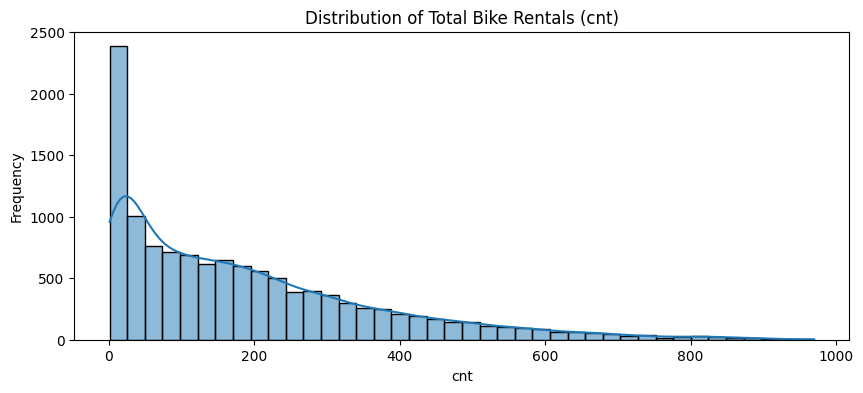

In [10]:
# EDA 1: Target distribution
print("=== Chart: Distribution of Total Bike Rentals (cnt) ===")
# Histogram dengan KDE untuk melihat distribusi target variable 'cnt'
plt.figure(figsize=(10, 4))
sns.histplot(df['cnt'], bins=40, kde=True)
plt.title('Distribution of Total Bike Rentals (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.show()

=== Chart: Correlation Matrix (Numeric Columns) ===


=== Chart: Correlation Matrix (Numeric Columns) ===


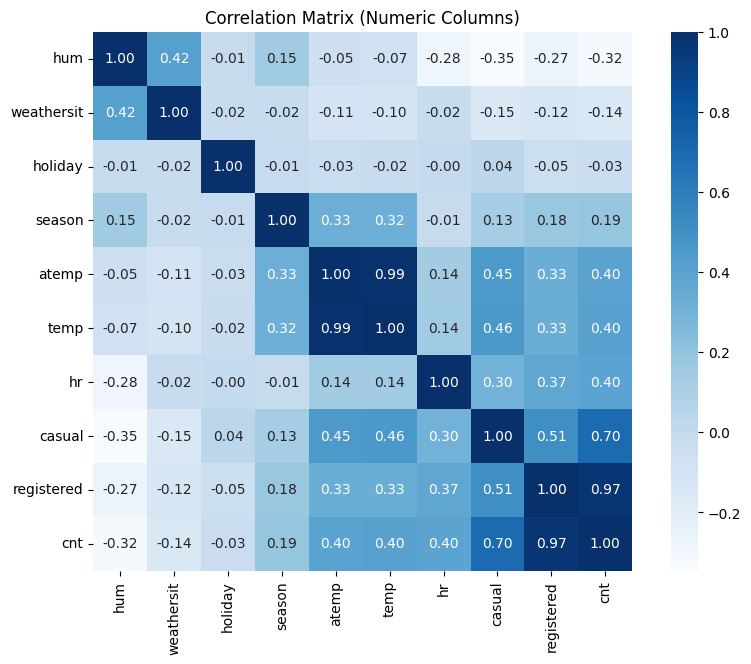

In [11]:
# EDA 2: Correlation heatmap (numeric features)
print("=== Chart: Correlation Matrix (Numeric Columns) ===")
# Memilih hanya kolom numerik untuk analisis korelasi
num_cols = df.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Correlation Matrix (Numeric Columns)')
plt.show()

=== Charts: Average Demand Pattern by Hour, Season, and Weather ===


=== Charts: Average Demand Pattern by Hour, Season, and Weather ===


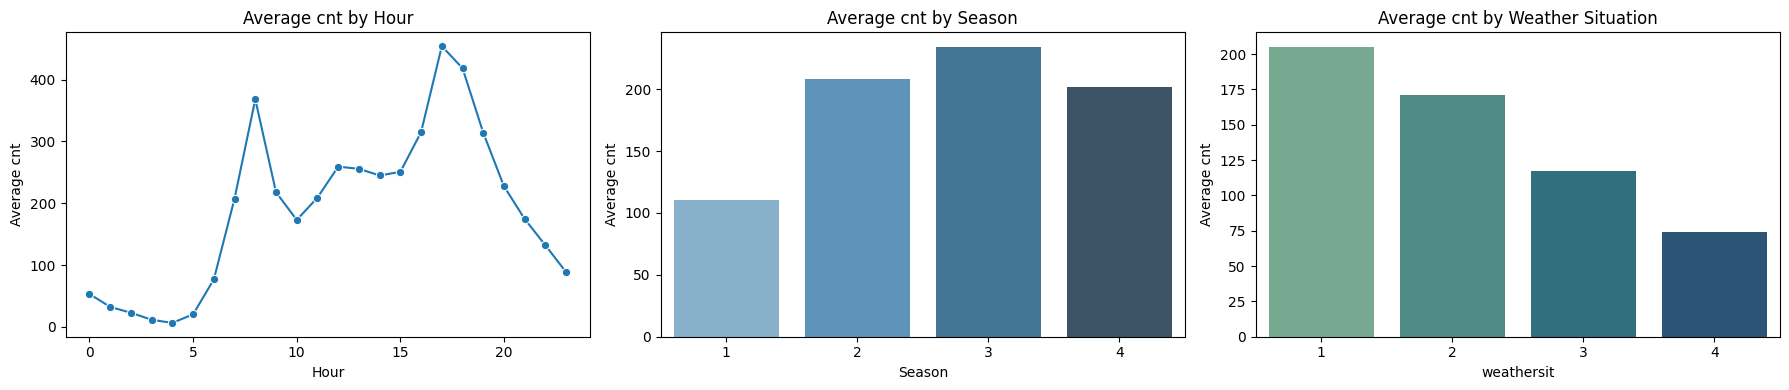

In [13]:
# EDA 3: Average demand patterns by: hour, season, and weather
print("=== Charts: Average Demand Pattern by: Hour, Season, and Weather ===")
# Membuat subplots untuk pola permintaan berdasarkan jam, musim, dan kondisi cuaca
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# untuk pola permintaan berdasarkan jam
hourly_pattern = df.groupby('hr', as_index=False)['cnt'].mean()
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', marker='o', ax=axes[0])
axes[0].set_title('Average cnt by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average cnt')

# untuk pola permintaan berdasarkan musim
season_pattern = df.groupby('season', as_index=False)['cnt'].mean()
sns.barplot(data=season_pattern, x='season', y='cnt', palette='Blues_d', ax=axes[1])
axes[1].set_title('Average cnt by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average cnt')

# untuk pola permintaan berdasarkan kondisi cuaca
weather_pattern = df.groupby('weathersit', as_index=False)['cnt'].mean()
sns.barplot(data=weather_pattern, x='weathersit', y='cnt', palette='crest', ax=axes[2])
axes[2].set_title('Average cnt by Weather Situation')
axes[2].set_xlabel('weathersit')
axes[2].set_ylabel('Average cnt')

plt.tight_layout()
plt.show()

### 3. Data Preprocessing
Tahap ini menyiapkan fitur untuk model regresi, termasuk konversi tanggal dan pemisahan train-test.

In [15]:
# Feature engineering and train-test split
# Exclude columns that can cause target leakage: cnt = casual + registered
data = df.copy()

data['dteday'] = pd.to_datetime(data['dteday'])
data['year'] = data['dteday'].dt.year
data['month'] = data['dteday'].dt.month
data['dayofweek'] = data['dteday'].dt.dayofweek

target_col = 'cnt'
leakage_cols = ['casual', 'registered']
feature_cols = [c for c in data.columns if c not in [target_col, 'dteday'] + leakage_cols]

X = data[feature_cols]
y = data[target_col]

categorical_features = ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']
categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== Train-Test Split Summary ===")
# Menampilkan jumlah baris dan kolom pada set train dan test
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

print("\n=== Feature Configuration ===")
# Menampilkan kolom yang dieksklusi karena target leakage, serta daftar fitur numerik dan kategorikal yang akan digunakan
print('Excluded leakage columns:', leakage_cols)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

=== Train-Test Split Summary ===
Train shape: (9732, 10)
Test shape : (2433, 10)

=== Feature Configuration ===
Excluded leakage columns: ['casual', 'registered']
Numeric features: ['hum', 'atemp', 'temp']
Categorical features: ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']


### 4. Modeling (Regression)
Model yang dibandingkan:
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor

In [22]:
# Train and compare multiple regression models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=250, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)

    rows.append({
        'model': name,
        'cv_mae': -cv_scores['test_mae'].mean(),
        'cv_rmse': -cv_scores['test_rmse'].mean(),
        'cv_r2': cv_scores['test_r2'].mean(),
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

    fitted_pipelines[name] = pipe

results = pd.DataFrame(rows).sort_values(by='test_rmse').reset_index(drop=True)
print("=== Model Comparison Results (Sorted by Test RMSE) ===")
# Menampilkan tabel perbandingan hasil model, diurutkan berdasarkan nilai RMSE pada set test
display(results)

=== Model Comparison Results (Sorted by Test RMSE) ===


,model,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
0,RandomForest,38.408985,60.613357,0.888817,34.801229,56.518114,0.897505
1,GradientBoosting,63.972770,88.919806,0.761642,62.342865,88.115439,0.750867
2,LinearRegression,75.669468,101.996866,0.686314,74.788030,101.186371,0.671473


In [23]:
# Select final model based on the lowest test RMSE
best_model_name = results.loc[0, 'model']
final_model = fitted_pipelines[best_model_name]

final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("=== Final Model Performance ===")
print(f'Final model: {best_model_name}')
print(f'MAE  : {final_mae:.4f}')
print(f'RMSE : {final_rmse:.4f}')
print(f'R2   : {final_r2:.4f}')

=== Final Model Performance ===
Final model: RandomForest
MAE  : 34.8012
RMSE : 56.5181
R2   : 0.8975


=== Diagnostic Charts for Final Model ===


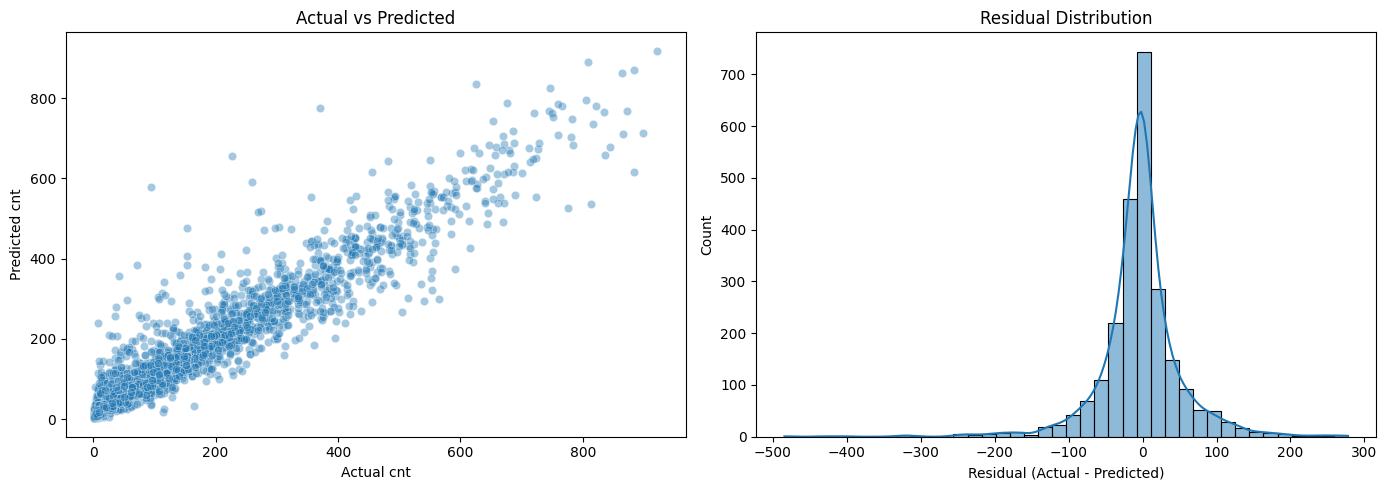

In [24]:
# Simple diagnostics: actual vs predicted and residual distribution
# Recompute prediction here so this cell can run safely after kernel restart.
if 'final_model' not in globals():
    raise NameError("final_model is not defined. Run the 'Select final model' cell first.")

print("=== Diagnostic Charts for Final Model ===")
final_pred = final_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=final_pred, alpha=0.4, ax=axes[0])
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual cnt')
axes[0].set_ylabel('Predicted cnt')

residuals = y_test - final_pred
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

### 5. Conclusion
Hasil modeling menunjukkan bahwa model terbaik untuk memprediksi jumlah penyewaan sepeda (`cnt`) adalah **RandomForest** berdasarkan nilai RMSE test paling rendah.

Ringkasan performa model final:
- **MAE: 34.8012**
- **RMSE: 56.5181**
- **R-squared: 0.8975**

Interpretasi hasil:
- Rata-rata kesalahan absolut model sekitar **35 unit sepeda** per observasi (MAE), sehingga model sudah cukup baik untuk membantu estimasi demand operasional.
- Nilai RMSE yang lebih besar dari MAE menunjukkan masih ada beberapa prediksi dengan error yang cukup besar, terutama pada kondisi demand ekstrem.
- Nilai R-squared sekitar **89.75%** menunjukkan model mampu menjelaskan sebagian besar variasi jumlah rental dari fitur yang tersedia.

Kesimpulan bisnis:
- Model dapat digunakan sebagai alat bantu perencanaan alokasi sepeda dan staffing, khususnya untuk pola demand normal.
- Model belum sepenuhnya optimal untuk kondisi ekstrem (misalnya cuaca sangat buruk atau lonjakan demand tidak biasa), sehingga hasil prediksi tetap perlu dikombinasikan dengan judgement operasional.

### 6. Recommendations
- Gunakan model untuk membantu perencanaan operasional (alokasi unit sepeda dan staffing) pada jam dengan demand tinggi.
- Lakukan retraining berkala agar model tetap relevan terhadap pola demand terbaru.
- Tambahkan fitur eksternal (misalnya event kota, kondisi cuaca detail, lokasi stasiun) untuk peningkatan performa.
- Terapkan monitoring performa model (drift data dan drift error) setelah implementasi.

### Save Model

In [38]:
# Save final regression model and metadata
artifact = {
    'model_name': best_model_name,
    'pipeline': final_model,
    'feature_columns': feature_cols,
    'target_column': target_col,
    'metrics': {
        'mae': float(final_mae),
        'rmse': float(final_rmse),
        'r2': float(final_r2)
    }
}

with open('best_bike_sharing_regression_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print("=== Model Artifact Saved ===")
print('Model saved to best_bike_sharing_regression_model.pkl')

Model saved to best_bike_sharing_regression_model.pkl
